In [474]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


# Computer vision
* we use the convolutional neural netword(CNN) for computer vision as they are more effective

### computer vision libraries
* torchvision `base domain library in pytorch for computervision`
* transforming and augumentation model
* `torchvision.datasets` - gets datasts and dataloading
* `torchvision.models` get the pretrained computer vision models for own problems
* `torchvision.transforms` - functions for manipulating the images to be suitable for ml model(conver the images to the numbers)
* `torch.utils.data.Dataset` base dataset class for pytorch
* `torch.utils.data.DataLoader`
* `toch.transforms.ToTensor` will convert the pli image or numpy array to tensor

In [475]:
## read the pytorch documentation in torchvision

In [476]:
print(torch.__version__)

2.4.1


In [477]:
print(torchvision.__version__)

0.19.1


## Get a dataset
* The dataset was used is FashionMNIST
* Greyscale images of clothing
* as MNIST was very easy so we use the fashionMNIST

In [478]:
## imagenet was gold standstandard for the computervision


In [479]:
## root,train,transform etc settings

## Setup the Training data

In [480]:
train_data=datasets.FashionMNIST(root='data',
                                 train=True,# do we need a training
                                 download=True,
                                 transform=torchvision.transforms.ToTensor(),
                                target_transform=None)
                                 

In [481]:
test_data=datasets.FashionMNIST(root='data',
                                train=False,
                                download=True,
                                transform=ToTensor(),
                                target_transform=None)

In [482]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [483]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [484]:
len(train_data),len(test_data)

(60000, 10000)

In [485]:
class_names=train_data.classes

In [486]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [487]:
class_to_inx=train_data.class_to_idx

In [488]:
class_to_inx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [489]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [490]:
print(f"the image shape is {image.shape}")

the image shape is torch.Size([32, 1, 28, 28])


In [491]:
label

tensor([5, 1, 3, 8, 4, 7, 9, 2, 6, 9, 4, 3, 3, 4, 3, 3, 9, 1, 0, 3, 3, 8, 5, 5,
        0, 9, 3, 3, 9, 6, 2, 1])

In [492]:
## we have only one color channel as it is in greyscale

## visualize in an image

In [493]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [494]:
## we can also set the batch size

In [495]:
## works with (NCHW) which means color channels first

In [496]:
## 1. visualize  our data

image shapetorch.Size([1, 28, 28])
torch.Size([28, 28])


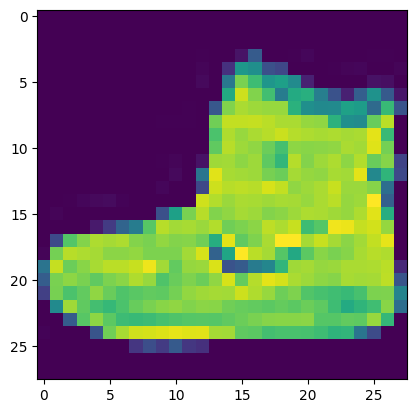

In [497]:
import matplotlib.pyplot as plt

image,label=train_data[0]
print(f"image shape{image.shape}")

plt.imshow(image.squeeze())

print(image.squeeze().shape)

In [498]:
# in grey scale


(-0.5, 27.5, 27.5, -0.5)

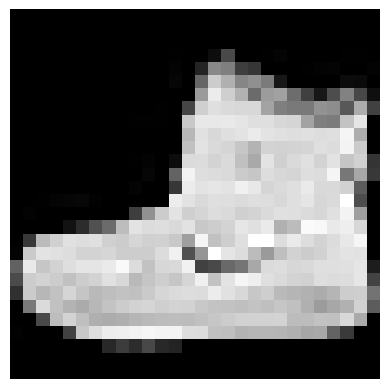

In [499]:
plt.imshow(image.squeeze(),cmap='gray')
plt.axis(False)

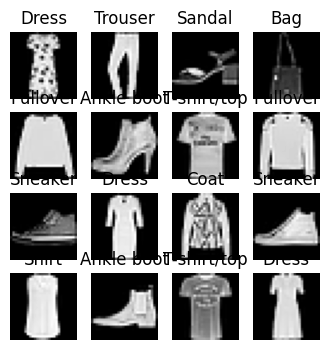

In [500]:

fig=plt.figure(figsize=(4,4))
rows,cols=4,4

for i in range(1,rows*cols+1,1):
    #print(i)
    random_idx=torch.randint(0,len(train_data),size=[1]).item()
    #print(random_idx)
    img,l=train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(class_names[l])
    plt.axis(False)

## we need some non-linearity to detect the items of clothing

In [501]:
## 2.prepare the data loader

train_data,test_data

In [502]:
## turns out 

In [503]:
train_data,test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## A Dataloader will convert the dataset to the iterable dataset
* more specifically we want to turn the data into the batches or minibatched

* We break the training samples into smaller batches for more compute efficiency or limited RAM so we break dowm the images to 32 image at a time / batch

* it gives the neural network more chances to update per each epoch

In [504]:
## we turn to the minibatchs to better parameters values in single epoch

In [505]:
## now by including the batch size the shape of the input goes to the
## (batch,color,height,width)
## (32,1,28,28) for the above example

In [506]:
## turnt he data into the dataloader and break into the batches

In [507]:
from torch.utils.data import DataLoader

In [508]:
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=32,
                            shuffle=True)

In [509]:
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=32,
                            shuffle=True)

In [510]:
# setup the batch size which was also a hyperparameter

# Hyper parameters were generally typed in Capital letters

In [511]:
test_dataloader=DataLoader(dataset=test_data,
                           batch_size=32,
                           shuffle=False)

In [512]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x30f954b60>,
 <torch.utils.data.dataloader.DataLoader at 0x30aad1e50>)

In [513]:
# let's check out what we had created

In [514]:
print(f"dataloaders {test_dataloader},{train_dataloader}")

dataloaders <torch.utils.data.dataloader.DataLoader object at 0x30aad1e50>,<torch.utils.data.dataloader.DataLoader object at 0x30f954b60>


In [515]:
len(train_dataloader)
## give the number of batches were there

1875

In [516]:
len(test_dataloader)

313

In [517]:
# show a sample

In [518]:
torch.manual_seed(42)
len(train_dataloader)

1875

In [519]:
train_features,train_labels=next(iter(train_dataloader))

In [520]:
print(len(train_features))
train_features

32


tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [521]:
train_labels

tensor([5, 7, 4, 7, 3, 8, 9, 5, 3, 1, 2, 3, 2, 3, 3, 7, 9, 9, 3, 2, 4, 6, 3, 5,
        5, 3, 2, 0, 0, 8, 4, 2])

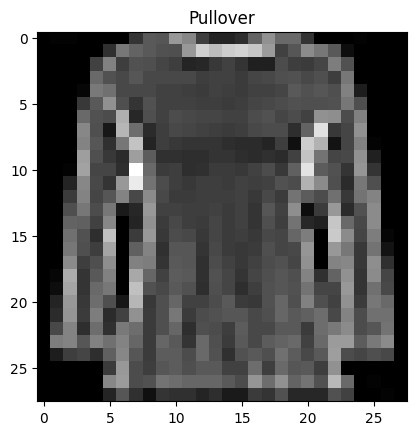

In [522]:
rnd=torch.randint(0,len(train_features),size=[1]).item()
img,label=train_features[rnd],train_labels[rnd]
plt.title(class_names[label])
plt.imshow(img.squeeze(),cmap='gray')



In [523]:
## now we can push them into the model


## we can now make one model now

In [524]:
len(train_features)

32

In [525]:
train_features.shape

torch.Size([32, 1, 28, 28])

In [526]:
from torch.utils.data import Dataset

## build a baseline model
* a baseline model was a simple model which we can improve on
* start simply and add complexity
* and avoid the overfitting


# creating a flatten layer

In [527]:
flatten_model=nn.Flatten()
## a single samepl
x=train_features[0]

In [528]:
x.shape
## color channels height ,width

torch.Size([1, 28, 28])

In [529]:
## flatten the sample
output=flatten_model(x)
print(f'shape before flattensing {x.shape}')
print(f'output shape {output.shape}')

#output=colorchannel,height*width

shape before flattensing torch.Size([1, 28, 28])
output shape torch.Size([1, 784])


In [530]:
## linear layer as a baseline model

In [531]:
class FashionMNIST(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
        super().__init__()
        self.layer_stack=nn.Sequential(
                                        nn.Flatten(),
                                        nn.Linear(in_features=input_shape,out_features=hidden_units),
                                        nn.ReLU(),
                                        nn.Linear(in_features=hidden_units,out_features=hidden_units),
                                        nn.ReLU(),
                                        nn.Linear(in_features=hidden_units,out_features=hidden_units),
                                        nn.ReLU(),
                                        nn.Linear(in_features=hidden_units,out_features=hidden_units),
                                        nn.ReLU(),
                                        nn.Linear(in_features=hidden_units,out_features=output_shape)
        )
    def forward(self,x):
        return self.layer_stack(x)
                                        

In [532]:
torch.manual_seed(42)

## setup model

model_0=FashionMNIST(input_shape=784,hidden_units=10,output_shape=10).to('mps')

In [533]:
## it comnines into a vector

In [534]:
dummy_x=torch.rand([1,1,28,28])

In [535]:
dummy_x.shape

torch.Size([1, 1, 28, 28])

In [536]:
x2=nn.Flatten(train_features.squeeze())

dummy_x

In [537]:
## 3.1 loss functin and optimizer and evaliation model

In [538]:
## loss function nn.CrossEntropyLoss
## optimizer=torch.optim.SGD()
## use the accuracy

In [539]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
    print('exist')

else:
    request=requests.get('https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py')
    with open('helper_functions.py','wb') as f:
        f.write(request.content)


exist


In [540]:
from helper_functions import accuracy_fn



In [541]:
accuracy_fn

<function helper_functions.accuracy_fn(y_true, y_pred)>

In [542]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

## creating a function to time our experiments

* accuracy and perfomance
* how fast it runs

* there is a tradeoff between them

In [543]:
from timeit import default_timer as timer
def print_train_time(start:float,end:float,device:torch.device=None):
    """print difference between the start and end time."""
    total_time=end-start
    print(f'train time of {device} :{total_time:.3f}')
    return total_time

In [544]:
start_time=timer()
end_time=timer()
print_train_time(start_time,end_time)

train time of None :0.000


1.4208002539817244e-05

In [545]:
## training loop

In [546]:
## the optimizer will update the model parameters once per batch not once epoch

## creating a training loop and training the model in 

1. loop through epochs
2. loop through batches ,perform training steps,calcualte train loss per batch
3. loop through testing batches, perform testing steps , calculate the test loss
4. print out summary
5. time it all

In [547]:
## import tqdm for progress bar

from tqdm.auto import tqdm

# set the seed and start timer

torch.manual_seed(42)
train_time_start_on_cpu=timer()

epochs=3

# Create a training and test loop

for epoch in tqdm(range(epochs)):
    print(f"epoch:{epoch}")
    train_loss=0
    ## add a loop to through the traingin batches
    for batch,(image,label) in enumerate(train_dataloader):
        
        model_0.train()
        y_pred=model_0(image.to('mps'))
        loss=loss_fn(y_pred,label.to('mps'))
        train_loss=train_loss+loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch%400==0:
            print(f"looked at {batch*len(x)}/{len(train_dataloader.dataset)} ")

    test_loss=0
    test_acc=0
    
    with torch.inference_mode():
        for i,l in test_dataloader:
            test_pred=model_0(i.to('mps'))
            test_loss+=loss_fn(test_pred,l.to('mps'))
            test_acc+=accuracy_fn(l.to('mps'),test_pred.argmax(dim=1))
        test_loss/=len(train_dataloader)
        test_acc/=len(test_dataloader)

    print(f"trainlos :{train_loss:.4f}|testloss :{test_loss:.4f}| test acc {test_acc}")
    
    
train_stop=timer()
print_train_time(train_time_start_on_cpu,train_stop)
        

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
looked at 0/60000 
looked at 400/60000 
looked at 800/60000 
looked at 1200/60000 
looked at 1600/60000 
trainlos :1881.1746|testloss :0.1001| test acc 77.7655750798722
epoch:1
looked at 0/60000 
looked at 400/60000 
looked at 800/60000 
looked at 1200/60000 
looked at 1600/60000 
trainlos :1099.7075|testloss :0.0970| test acc 78.88378594249201
epoch:2
looked at 0/60000 
looked at 400/60000 
looked at 800/60000 
looked at 1200/60000 
looked at 1600/60000 
trainlos :987.8046|testloss :0.0862| test acc 82.13857827476038
train time of None :15.689


15.688508709004964

In [548]:
print(train_data.class_to_idx)

{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [549]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0297, -0.0086,  ..., -0.0146,  0.0092,  0.0134],
                      [-0.0187, -0.0355,  0.0251,  ...,  0.0887,  0.0280,  0.0178],
                      [-0.0008,  0.0017,  0.0044,  ..., -0.0131, -0.0190,  0.0058],
                      ...,
                      [-0.0116,  0.0273, -0.0345,  ...,  0.0179,  0.0281, -0.0012],
                      [-0.0232,  0.0247,  0.0246,  ...,  0.0256,  0.0014,  0.0003],
                      [ 0.0175, -0.0148,  0.0033,  ..., -0.0432, -0.0300,  0.0191]],
                     device='mps:0')),
             ('layer_stack.1.bias',
              tensor([ 0.2161,  0.3876, -0.0164,  0.2830, -0.1516,  0.4360,  0.4364, -0.0059,
                      -0.0911,  0.1521], device='mps:0')),
             ('layer_stack.3.weight',
              tensor([[-0.0452,  0.4059, -0.0089, -0.5060,  0.0123,  0.1540, -1.3758, -0.1067,
                        0.5896,  0.6972],
                      [ 0.0

In [550]:
## make predicitons to get the model0 results

In [551]:
## predicitons for model_0



In [552]:
def eval_model(model:torch.nn.Module,data_loader,loss_fn,accuracy_fn):
    ## return the dicitonary to that contains the results 
    model.eval()
    loss=0,
    acc=0,
    with torch.inference_mode():
        for x,y in data_loader:
            y_pred=model(x)
            # accumulate the loss and acc values per batch
            loss+=loss_fn(y_pred,y)
            acc+=accuracy_fn(y,y_pred.argmax(dim=1))

        loss=loss/len(data_loader)
        acc=acc/len(data_loader)

    return {'model_name':model.__class__.__name__,
            'model_loss':loss.item(),
            'model_acc':acc}
    


In [553]:
## a loss function


## setup some device agnostic code

In [554]:
torch.backends.mps.is_available()

True

## sometimes depending upon the data it may run fast on cpu than gpu 

* due tot he overhead of the data copy between cpu and gpu which will be dominating the speed of the gpu

* the hardware we are using we have the better cpu

* how to get most of the gpus

In [555]:
class FashionMNIST(nn.Module):
    """model alchitectute that replicats tinyVGG"""
    def __init__(self,input_shape,hidden_units,output_shape):
        super().__init__()
        self.conv_block_1=nn.Sequential(
                                            nn.Conv2d(in_channels=input_shape,out_channels=hidden_units,
                                                     kernel_size=3,
                                                     stride=1,
                                                     padding=1),
                                            nn.ReLU(),
                                            nn.Conv2d(in_channels=hidden_units,
                                                      out_channels=hidden_units,
                                                      kernel_size=3,
                                                      stride=1,
                                                      padding=1),
                                            nn.ReLU(),
                                            nn.MaxPool2d(kernel_size=2)
        )
        self.conv_block_2=nn.Sequential(
                                            nn.Conv2d(in_channels=hidden_units,
                                                      out_channels=hidden_units,
                                                      kernel_size=3,
                                                      padding=1,
                                                      stride=1),
                                            nn.ReLU(),
                                            nn.Conv2d(in_channels=hidden_units,
                                                      out_channels=hidden_units,
                                                      kernel_size=3,
                                                      stride=1,
                                                      padding=1),
                                            nn.ReLU(),
                                            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier=nn.Sequential(
                            nn.Flatten(),
                            nn.Linear(in_features=hidden_units*7*7,
                                      out_features=output_shape)
        )

    def forward(self,x):

        return self.classifier(self.conv_block_2(self.conv_block_1(x)))
            
                                            
            # kernerl_size,stride,pride were the hyper parameters which can be set manually

In [556]:
model=FashionMNIST(input_shape=1,hidden_units=10,output_shape=10).to('mps')

In [557]:
## stepping through nn.Conv2d()

In [558]:
## dummy data

In [559]:
torch.manual_seed(42)

images=torch.randn(size=(32,3,64,64))
test_image=images[0]
print(images.shape)
print(test_image.shape)

torch.Size([32, 3, 64, 64])
torch.Size([3, 64, 64])


In [560]:
model.state_dict()


OrderedDict([('conv_block_1.0.weight',
              tensor([[[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
                      [[[-0.1457,  0.1924,  0.0596],
                        [ 0.1693, -0.2032, -0.3300],
                        [-0.1288, -0.2557,  0.2735]]],
              
              
                      [[[ 0.0960,  0.1381,  0.1054],
                        [-0.0058,  0.2609, -0.2368],
                        [ 0.0210, -0.2275,  0.1028]]],
              
              
      

In [561]:
# create a single conv2d layer
conv_layer=nn.Conv2d(in_channels=3,out_channels=64,
                     kernel_size=3,
                     padding=0,
                     stride=1)

## kernels could be (3,3)

In [562]:
conv_layer(test_image).shape

torch.Size([64, 62, 62])

In [563]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

In [564]:
torch.__version__

'2.4.1'

In [565]:
## breaking down of the nn.MaxPool2d layer

In [566]:
## test image we had created

In [567]:
# printout the original image shape withput unsqueeze() layer


In [568]:
test_image.shape

torch.Size([3, 64, 64])

In [569]:
test_image.unsqueeze(1).shape

torch.Size([3, 1, 64, 64])

In [570]:
max_pool_layer=nn.MaxPool2d(kernel_size=2)
test_image_through_conv=conv_layer(test_image.unsqueeze(0))

In [571]:
test_image_through_conv.shape

torch.Size([1, 64, 62, 62])

In [572]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

In [573]:
test_image_through_conv_maxpool=max_pool_layer(test_image_through_conv)

In [574]:
test_image_through_conv_maxpool.shape


torch.Size([1, 64, 31, 31])

In [575]:
torch.manual_seed(42)

maxpool=nn.MaxPool2d(kernel_size=2)
random=torch.randn(size=(1,1,2,2))
random

random_max_pool=maxpool(random)
random_max_pool
print(random_max_pool.shape)

torch.Size([1, 1, 1, 1])


In [576]:
## tiny VGG



In [577]:
img.shape

torch.Size([1, 28, 28])

In [578]:
model

FashionMNIST(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [579]:
rand_image_tensor=torch.randn(size=(1,28,28))
rand_image_tensor.shape
rand_image_tensor=rand_image_tensor.to('mps')

In [580]:
model(rand_image_tensor.unsqueeze(0))

tensor([[-0.0150, -0.1063,  0.0258, -0.1314,  0.0145, -0.0282, -0.0323,  0.0841,
         -0.0272, -0.0298]], device='mps:0', grad_fn=<LinearBackward0>)

In [581]:
torch.argmax(model(rand_image_tensor.unsqueeze(0)))

tensor(7, device='mps:0')

In [582]:
## train out first convolutional neural network


In [583]:
## training the cnn


In [584]:
### setup a lossfunction and optimizer

In [585]:
## lossfunction/eval matrices/optimizer

from helper_functions import accuracy_fn
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)
print(accuracy_fn)

<function accuracy_fn at 0x30832e520>


In [586]:
model.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[-0.1556,  0.0850, -0.1536],
                        [-0.0391, -0.1354,  0.2211],
                        [-0.2631, -0.1537, -0.0941]]],
              
              
                      [[[-0.2004,  0.0315, -0.3292],
                        [ 0.3010, -0.2832,  0.2573],
                        [ 0.0555, -0.1082,  0.2060]]],
              
              
                      [[[ 0.0520,  0.2693,  0.0364],
                        [-0.1051,  0.0896, -0.0904],
                        [ 0.1403,  0.2976,  0.1927]]],
              
              
                      [[[-0.1457,  0.1924,  0.0596],
                        [ 0.1693, -0.2032, -0.3300],
                        [-0.1288, -0.2557,  0.2735]]],
              
              
                      [[[ 0.0960,  0.1381,  0.1054],
                        [-0.0058,  0.2609, -0.2368],
                        [ 0.0210, -0.2275,  0.1028]]],
              
              
      

In [587]:
## model trainingand testing  cnn model
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device):
    train_loss,train_acc=0,0
    model.to(device)
    for batch,(x,y) in enumerate(data_loader):
        x,y=x.to(device),y.to(device)
        y_pred=model(x)
        loss=loss_fn(y_pred,y)
        train_loss=train_loss+loss
        train_acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss/=len(data_loader)
    train_acc/=len(data_loader)
    print(f"train_loss {train_loss} tacc : {train_acc}")
        

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device):
    test_loss, test_acc = 0, 0
    model.to('mps')
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to('mps'), y.to('mps')
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1) # Go from logits -> pred labels
            )
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [589]:
torch.manual_seed(42)
from timeit import default_timer as timer
start_time=timer()
## train model

epochs=30
print(accuracy_fn)
for epoch in tqdm(range(epochs)):
    print(f"epoch:{epoch}\n-------")
    train_step(model,train_dataloader,loss_fn,optimizer,accuracy_fn,'mps')
    test_step(test_dataloader,model,loss_fn,accuracy_fn,'mps')

<function accuracy_fn at 0x30832e520>


  0%|          | 0/30 [00:00<?, ?it/s]

epoch:0
-------
train_loss 0.23748348653316498 tacc : 91.47
Test loss: 0.28199 | Test accuracy: 89.96%

epoch:1
-------
train_loss 0.23600177466869354 tacc : 91.54833333333333
Test loss: 0.27476 | Test accuracy: 90.40%

epoch:2
-------
train_loss 0.23368948698043823 tacc : 91.59166666666667
Test loss: 0.27852 | Test accuracy: 90.27%

epoch:3
-------
train_loss 0.23175719380378723 tacc : 91.715
Test loss: 0.27211 | Test accuracy: 90.51%

epoch:4
-------
train_loss 0.22993287444114685 tacc : 91.705
Test loss: 0.27537 | Test accuracy: 90.19%

epoch:5
-------
train_loss 0.2283090502023697 tacc : 91.79
Test loss: 0.27312 | Test accuracy: 90.46%

epoch:6
-------
train_loss 0.22683420777320862 tacc : 91.77833333333334
Test loss: 0.27592 | Test accuracy: 90.43%

epoch:7
-------
train_loss 0.22506068646907806 tacc : 91.84
Test loss: 0.27502 | Test accuracy: 90.22%

epoch:8
-------
train_loss 0.2235029637813568 tacc : 91.89833333333333
Test loss: 0.27483 | Test accuracy: 90.49%

epoch:9
-------
